### Importing the needed libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Reading the data and understanding the columns

In [2]:
df = pd.read_csv("../_data/ShelterDogs.csv")
print("Shape of the dataframe:")
print(df.shape)
df.head()

Shape of the dataframe:
(2937, 19)


,ID,name,age,sex,breed,date_found,adoptable_from,posted,color,coat,size,neutered,housebroken,likes_people,likes_children,get_along_males,get_along_females,get_along_cats,keep_in
0,23807,Gida,0.25,female,Unknown Mix,2019-12-10,2019-12-11,2019-12-11,red,short,small,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,533,Frida És Ricsi,0.17,female,Unknown Mix,2019-12-01,2019-12-01,2019-12-09,black and white,short,small,no,NaN,yes,yes,yes,yes,yes,NaN
2,23793,NaN,4.00,male,Unknown Mix,2019-12-08,2019-12-23,2019-12-08,saddle back,short,medium,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23795,NaN,1.00,male,Unknown Mix,2019-12-08,2019-12-23,2019-12-08,yellow-brown,medium,medium,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,23806,Amy,2.00,female,French Bulldog Mix,2019-12-10,2019-12-11,2019-12-11,black,short,small,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN


| Column | Description |
|------|-------------|
| **ID** | Unique identification number of the dog |
| **name** | Name of the dog |
| **age** | Age of the dog in years (continuous variable) |
| **sex** | Sex of the dog |
| **breed** | Breed of the dog |
| **date_found** | Date when the dog was found |
| **adoptable_from** | Date when the dog became available for adoption |
| **posted** | Date when the dog was listed in the database |
| **color** | Color of the dog |
| **coat** | Pattern/type of the dog's coat |
| **size** | Size category of the dog |
| **neutered** | Whether the dog is neutered |
| **housebroken** | Whether the dog is housebroken |
| **likes_people** | Indicates if the dog likes people |
| **likes_children** | Indicates if the dog likes children |
| **get_along_males** | Indicates if the dog gets along with male dogs |
| **get_along_females** | Indicates if the dog gets along with female dogs |
| **get_along_cats** | Indicates if the dog gets along with cats |
| **keep_in** | Recommended environment to keep the dog |

### Simple EDA

In [3]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [4]:
duplicate_rows = df[df["ID"].duplicated(keep=False)]
duplicate_rows_sorted = duplicate_rows.sort_values(by="ID")
duplicate_rows_sorted.shape

(1849, 19)

##### We see that there are a lot of duplicated ID-s in the dataframe, however from the metadata we knew that ID is the unique identifier for the dog. Let's see what need to be done with that column

In [5]:
# Dropping "ID" column and then dropping duplicates
df = df.drop(columns=["ID"])
print(df.duplicated().sum())
df = df.drop_duplicates()

17


In [6]:
df.dtypes

name                     str
age                  float64
sex                      str
breed                    str
date_found               str
adoptable_from           str
posted                   str
color                    str
coat                     str
size                     str
neutered                 str
housebroken              str
likes_people             str
likes_children           str
get_along_males          str
get_along_females        str
get_along_cats           str
keep_in                  str
dtype: object

In [7]:
# Changing datetime column to a proper format
date_cols = ["date_found", "adoptable_from", "posted"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

##### Distribution of different features of the dataset

In [8]:
binary_cols = [
    "neutered",
    "housebroken",
    "likes_people",
    "likes_children",
    "get_along_males",
    "get_along_females",
    "get_along_cats"
]
binary_summary = pd.DataFrame({
    col: df[col].value_counts(dropna=False)
    for col in binary_cols
}).fillna(0)
binary_summary = binary_summary.reindex(["yes", "no", np.nan])
binary_summary.index = ["Yes", "No", "NaN"]
binary_summary

,neutered,housebroken,likes_people,likes_children,get_along_males,get_along_females,get_along_cats
Yes,1140,400,1985,1166,1463,1589,271
No,696,55,8,47,163,78,156
NaN,1084,2465,927,1707,1294,1253,2493


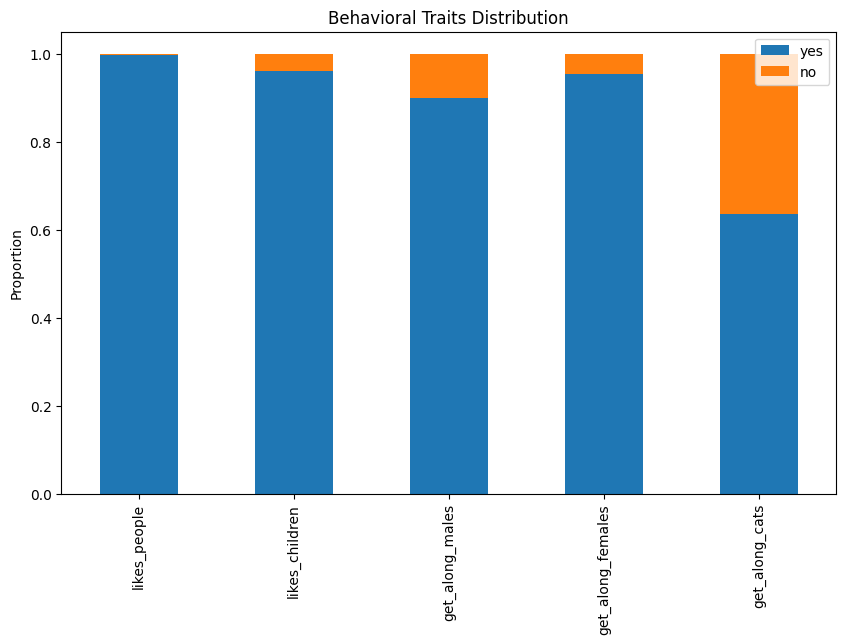

In [9]:
behavior_cols = [
    "likes_people",
    "likes_children",
    "get_along_males",
    "get_along_females",
    "get_along_cats"
]

behavior_counts = pd.DataFrame({
    col: df[col].value_counts(normalize=True)
    for col in behavior_cols
}).T

behavior_counts.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Behavioral Traits Distribution")
plt.ylabel("Proportion")
plt.show()

##### As expected most of the dogs (proportion) do not get well along with cats

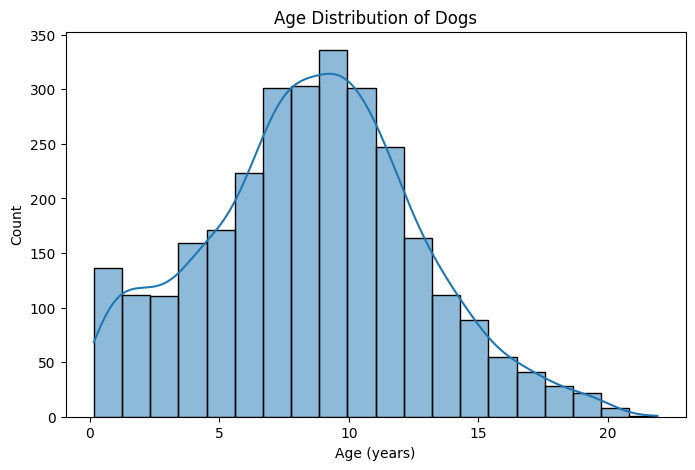

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution of Dogs")
plt.xlabel("Age (years)")
plt.show()

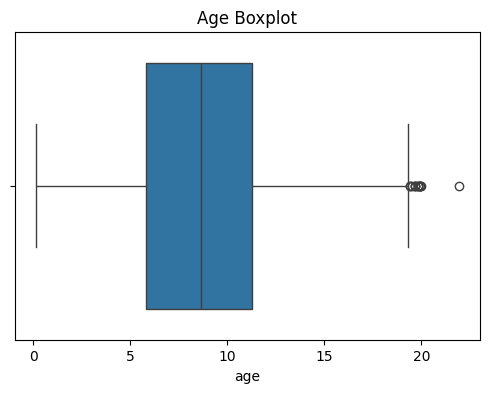

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.show()

##### As it can be observed the age of the dogs has right skewed distribution, and most of the dogs are within 6 to 12 years old (with some outliers according to the boxplot)

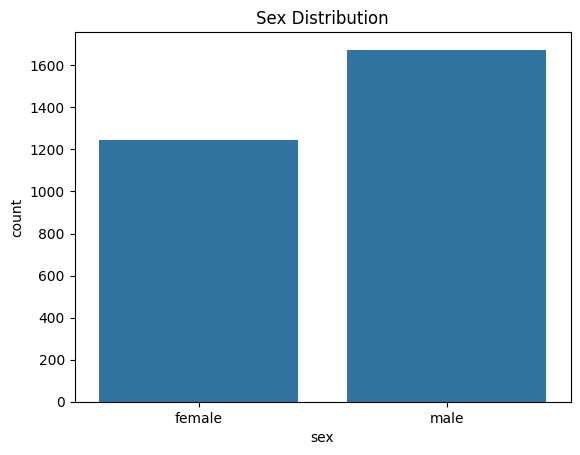

In [12]:
sns.countplot(data=df, x="sex")
plt.title("Sex Distribution")
plt.show()

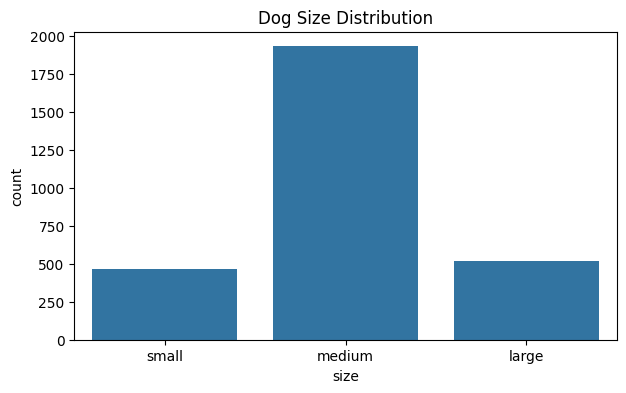

In [13]:
plt.figure(figsize=(7,4))

sns.countplot(data=df, x="size")

plt.title("Dog Size Distribution")
plt.show()

##### As most of the dataset has breed = "Unknown Mix", visualization will exclude that

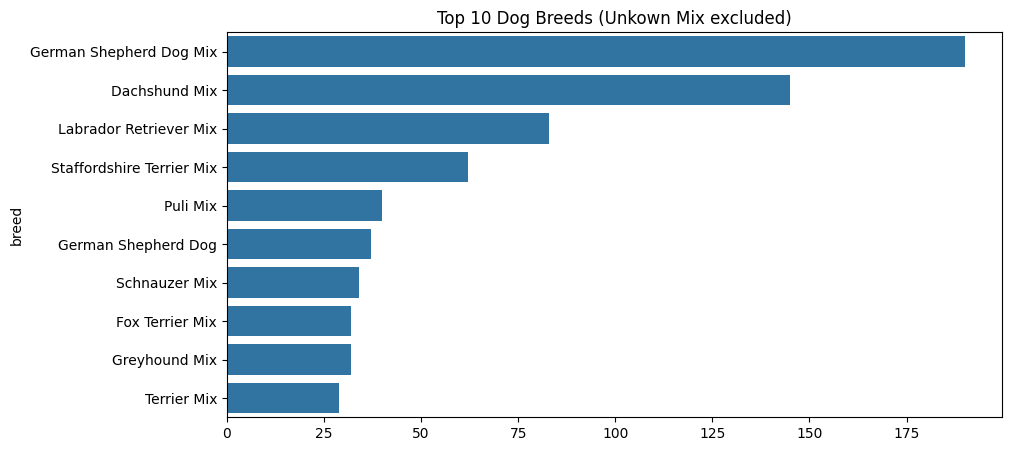

In [14]:
top_breeds = df[df["breed"] != "Unknown Mix"]["breed"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_breeds.values, y=top_breeds.index)

plt.title("Top 10 Dog Breeds (Unkown Mix excluded)")
plt.show()

### NaN Values

In [15]:
df.isna().sum().sort_values(ascending=False)

get_along_cats       2493
housebroken          2465
likes_children       1707
get_along_males      1294
get_along_females    1253
neutered             1084
keep_in              1017
likes_people          927
name                   90
age                     0
size                    0
coat                    0
color                   0
posted                  0
adoptable_from          0
date_found              0
breed                   0
sex                     0
dtype: int64

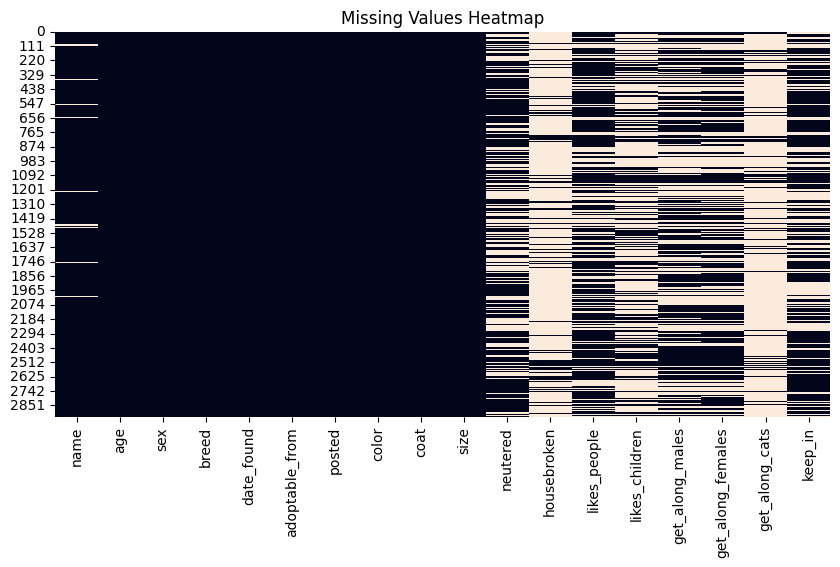

In [16]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

##### Interesting fact is that sometimes we have likes_people as NaN, but likes_children is "Yes". Let's deal with that

In [17]:
print("Likes children, but have no information for likes people:", df[df["likes_people"].isna() & (df["likes_children"] == "yes")].shape[0])

Likes children, but have no information for likes people: 50


##### Here we see that indeed we have such cases

In [18]:
df.loc[(df["likes_people"].isnull()) & (df['get_along_males'] == 'yes'), 'likes_people'] = 'yes'
df.loc[(df["likes_people"].isnull()) & (df['get_along_females'] == 'yes'), 'likes_people'] = 'yes'
df.loc[(df["likes_people"].isnull()) & (df['likes_children'] == 'yes'), 'likes_people'] = 'yes'

In [19]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
get_along_cats,2493,85.376712
housebroken,2465,84.417808
likes_children,1707,58.458904
get_along_males,1294,44.315068
get_along_females,1253,42.910959
neutered,1084,37.123288
keep_in,1017,34.828767
likes_people,736,25.205479
name,90,3.082192
age,0,0.000000


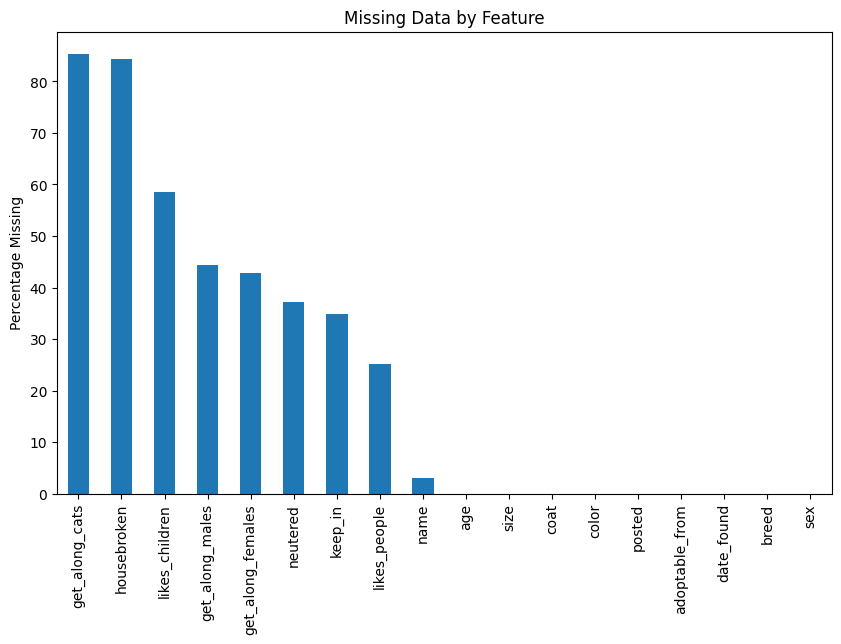

In [20]:
missing_percent = df.isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10,6))
missing_percent.plot(kind="bar")
plt.ylabel("Percentage Missing")
plt.title("Missing Data by Feature")
plt.show()

##### Filling some of the NaN-s

In [21]:
binary_cols = [
    "neutered","housebroken","likes_people","likes_children",
    "get_along_males","get_along_females","get_along_cats"
]

df[binary_cols] = df[binary_cols].fillna("unknown")

df.isna().sum().sort_values(ascending=False)

keep_in              1017
name                   90
age                     0
sex                     0
date_found              0
breed                   0
posted                  0
color                   0
coat                    0
adoptable_from          0
size                    0
neutered                0
likes_people            0
housebroken             0
likes_children          0
get_along_males         0
get_along_females       0
get_along_cats          0
dtype: int64

In [22]:
print(df["keep_in"].value_counts(dropna=False))
df["keep_in"] = df["keep_in"].fillna("unknown")

keep_in
both flat and garden    1215
NaN                     1017
garden                   506
flat                     182
Name: count, dtype: int64


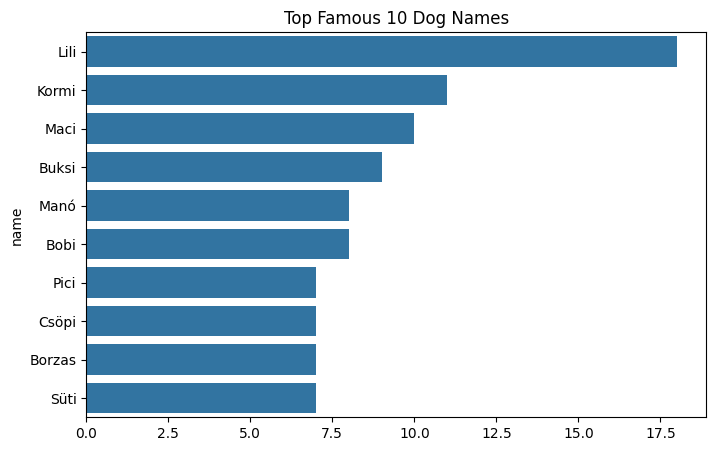

In [23]:
top_names = df["name"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_names.values, y=top_names.index)
plt.title("Top Famous 10 Dog Names")
plt.show()

##### Column `name` has high cardinality and will dropped later, however it was interesting to see famous names

### Investigating relationships between variables

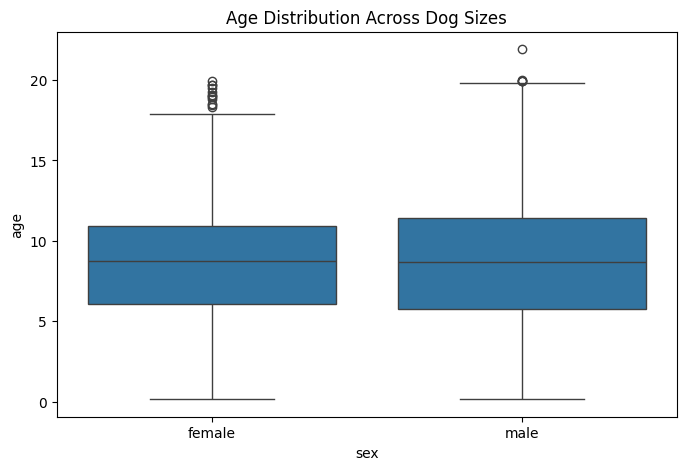

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="sex", y="age")

plt.title("Age Distribution Across Dog Sizes")
plt.show()

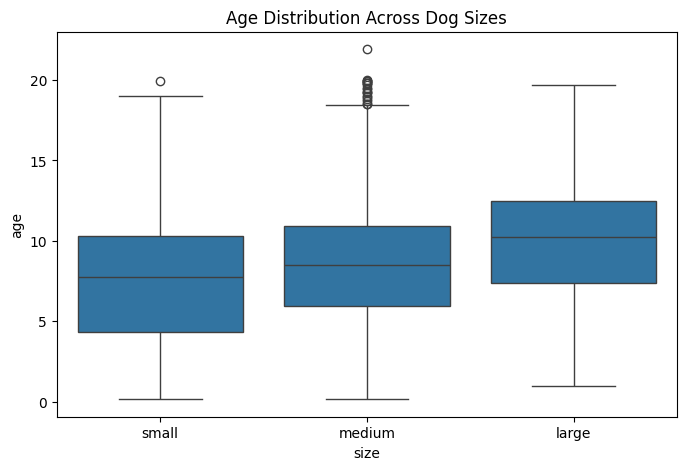

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="size", y="age")

plt.title("Age Distribution Across Dog Sizes")
plt.show()

##### As the medium sized dogs are more present in the data, it was not surprise to see more outliers for them. There is some little positive relation between the size and age of the dogs. No difference between different sex

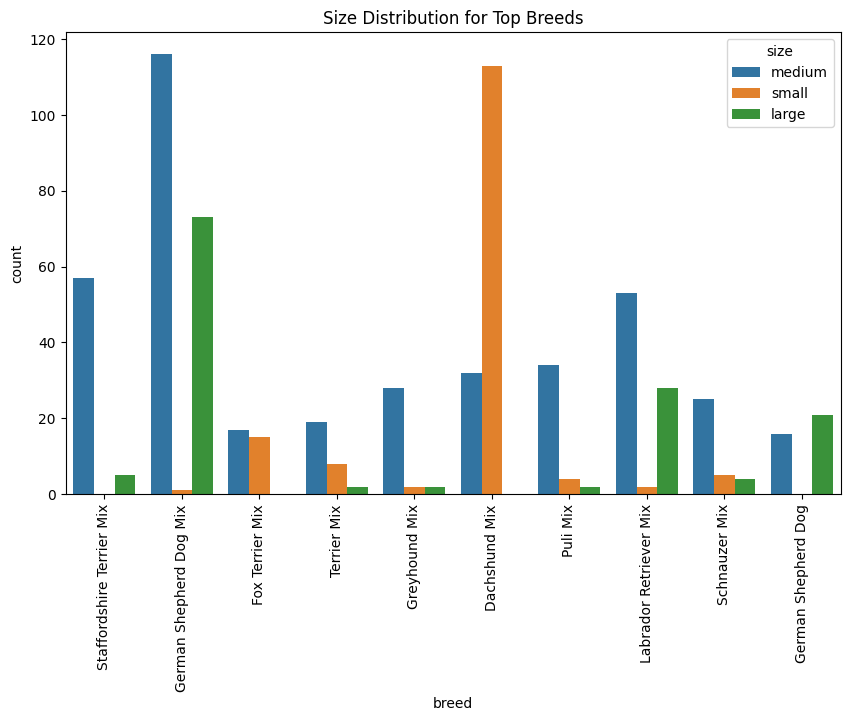

In [26]:
top_breeds = df[df["breed"] != "Unknown Mix"]["breed"].value_counts().head(10)
subset = df[df["breed"].isin(top_breeds.index)]

plt.figure(figsize=(10,6))
sns.countplot(data=subset, x="breed", hue="size")
plt.xticks(rotation=90)
plt.title("Size Distribution for Top Breeds")
plt.show()

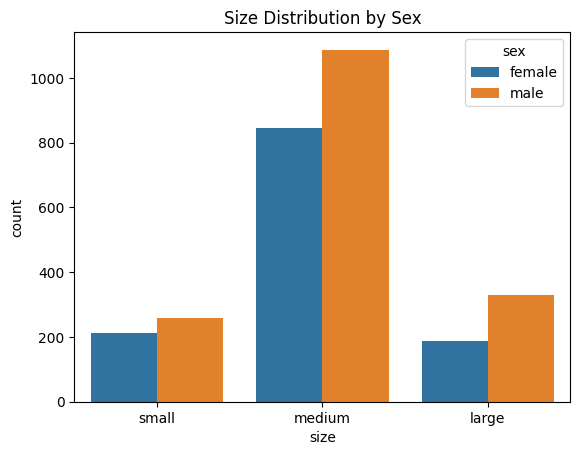

In [27]:
sns.countplot(data=df, x="size", hue="sex")

plt.title("Size Distribution by Sex")
plt.show()

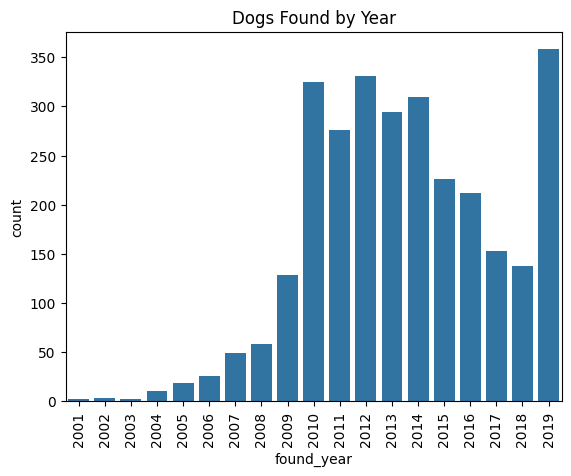

In [28]:
df["found_year"] = df["date_found"].dt.year

sns.countplot(data=df, x="found_year")

plt.title("Dogs Found by Year")
plt.xticks(rotation=90)
plt.show()

##### Very interesting, however we can't exactly say, if in 2000-s dogs haven't been found much, may be data wasn't properly collected. Nevertheless 2019 spike is interesting.

<Figure size 1000x600 with 0 Axes>

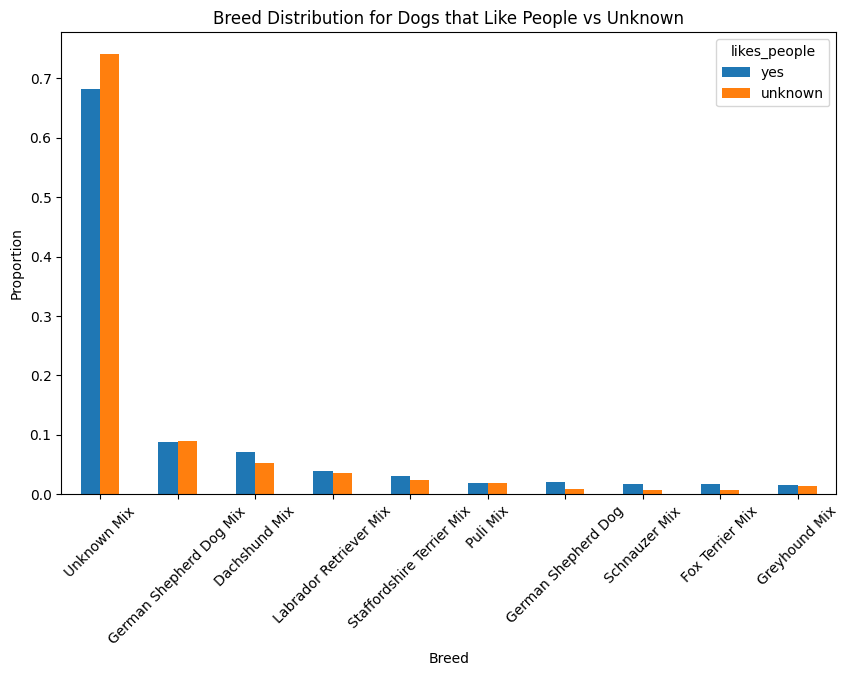

In [29]:
df_yes = df[df["likes_people"] == "yes"]
df_unknown = df[df["likes_people"] == "unknown"]

top_breeds = df["breed"].value_counts().head(10).index

df_yes = df_yes[df_yes["breed"].isin(top_breeds)]
df_unknown = df_unknown[df_unknown["breed"].isin(top_breeds)]

yes_prop = df_yes["breed"].value_counts(normalize=True)
unknown_prop = df_unknown["breed"].value_counts(normalize=True)

prop_df = pd.DataFrame({
    "yes": yes_prop,
    "unknown": unknown_prop
}).fillna(0)

prop_df = prop_df.loc[top_breeds]

plt.figure(figsize=(10,6))

prop_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Breed Distribution for Dogs that Like People vs Unknown")
plt.ylabel("Proportion")
plt.xlabel("Breed")
plt.xticks(rotation=45)

plt.legend(title="likes_people")

plt.show()

##### This plot was created to investigate one of our hypotheses. However, since the dataset contains a very small number of observations where `likes_people = "no"`, we instead compared dogs with `likes_people = "yes"` to those with `likes_people = "unknown"`.

##### From the visualization, we do not observe any meaningful differences in the breed distribution between these two groups.

##### Further decisions regarding the direction of the analysis and the remaining parts of the project will be made based on additional exploration of the dataset.

#### *During EDA, a lot of data processing steps have been conducting, that is why here, one more step is added to keep the processed data for future*

In [30]:
df['name'] = df['name'].fillna('Unknown')

df.to_csv('../_output/processed_dogs.csv', index=False)